# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

### Business framing:  

### Do the following:
Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows
- Show summary statistics for the dataframe

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

hotels = pd.read_csv("/hotels.csv")

display(hotels.head())
display(hotels.describe())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### Reflection:
1. What stands out in the initial preview? Any columns or rows that seem unusual?

### ✍️ Your Response: 🔧
1. In initial preview, what stood out to me was that the max for the lead time is 737 days but the ADR is 5,400 which is way higher, meaning that some of the values are super extreme. There are also some missing values in children, country, agent, and company.

## 2. Select and Prepare Features

### Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

### Do the following:
- 2.1 Choose 3–5 numeric features related to customer behavior
- 2.2 Perform basic data preparation - remove outliers, remove duplicates, correct any datatypes that need adjustment
- 2.3 Drop missing values if needed
- 2.4 Standardize using `StandardScaler` for any large values  (over 100)

In [8]:
features = ["lead_time", "stays_in_weekend_nights", "stays_in_week_nights", "adr", "total_of_special_requests"]

cluster_data = hotels[features].copy()

# Remove duplicates and missing values
cluster_data = cluster_data.drop_duplicates()
cluster_data = cluster_data.dropna()

# Remove outliers using IQR
for col in features:
    Q1 = cluster_data[col].quantile(0.25)
    Q3 = cluster_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    cluster_data = cluster_data[(cluster_data[col] >= lower) & (cluster_data[col] <= upper)]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data[features])

print(cluster_data.shape)
display(cluster_data.head())

(65742, 5)


,lead_time,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests
2,7,0,1,75.0,0
3,13,0,1,75.0,0
4,14,0,2,98.0,1
6,0,0,2,107.0,0
7,9,0,2,103.0,1


### Reflection:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?

### ✍️ Your Response: 🔧
1. I selected lead time, weekday nights, weekend nights, ADR, and total special requests because they describe how guests book, how long they stay, how much they're paying, anything that's meaningful.

2. I expect to find segments of guests who book super early in advance, guests who book last minute, guests who have longer stays, and guests who make special requests.


## 3. Apply K-Means Clustering

### Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

### Do the following:
- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign a cluster number to each guest
- Visualize the clusters using a scatterplot of 2 features
- Do a second visualization using a scatterplot of 2 different features
- Create a summary table to show the averages for each variable, broken out by cluster (this will show which variables stand out for each cluster)

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

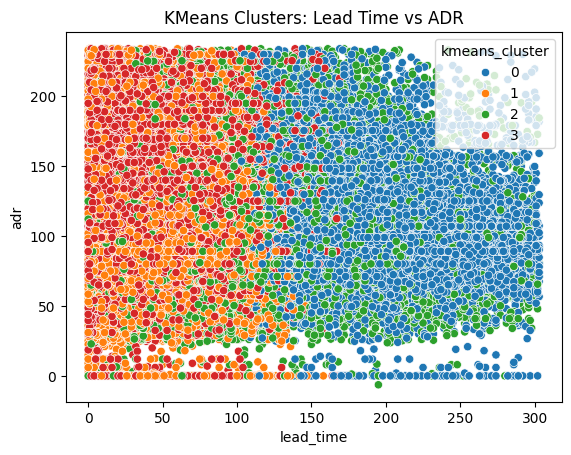

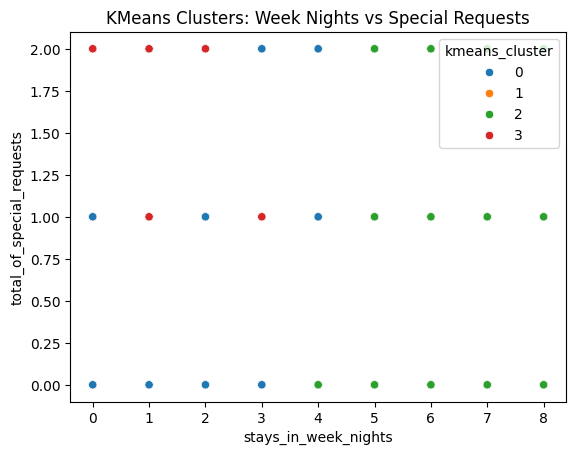

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests
kmeans_cluster,,,,,
0,187.684763,0.871276,2.475835,110.106310,0.620448
1,38.686825,0.760929,1.923808,100.806627,0.000000
2,115.767375,2.120196,5.078005,106.422963,0.622813
3,40.604678,0.754424,1.982875,111.836042,1.329844


In [9]:
k = 4

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_data["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

# Visualization 1
sns.scatterplot(data=cluster_data, x="lead_time", y="adr", hue="kmeans_cluster", palette="tab10")
plt.title("KMeans Clusters: Lead Time vs ADR")
plt.show()

# Visualization 2
sns.scatterplot(data=cluster_data, x="stays_in_week_nights", y="total_of_special_requests", hue="kmeans_cluster", palette="tab10")
plt.title("KMeans Clusters: Week Nights vs Special Requests")
plt.show()

# Cluster averages
kmeans_summary = cluster_data.groupby("kmeans_cluster")[features].mean()

display(kmeans_summary)

### Reflection:
1. What `k` value did you choose, and how did you decide?

2. For each cluster answer the following - what types of customers seem to show up in the cluster?  which variables are most prominent or important for that cluster?  

### ✍️ Your Response: 🔧
1. I chose k=4 because there is a reasonable balance between the clustering and customer groups. This makes it easy to interpret.

2. For Cluster 0, early planners seem to show up (booked 188 days in advance). For Cluster 1, shorter-term , lower-engagamenet guests (book about 39 days early and make little to no special requests). For Cluster 2, long-stay guests (highest number of weekend and weekday nights). And lastly for Cluster 3, higher-service guests seem to show up in the cluster (makes the most special request and highest avg ADR).


## 4. Apply Gaussian Mixture Model (GMM)

### Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

### Do the following:
- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the clusters using a scatterplot of 2 features
- Do a second visualization using a scatterplot of 2 different features
- Create a summary table to show the averages for each variable, broken out by cluster (this will show which variables stand out for each cluster)

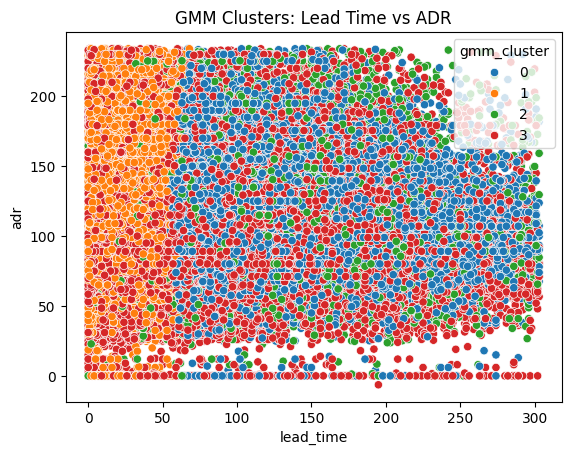

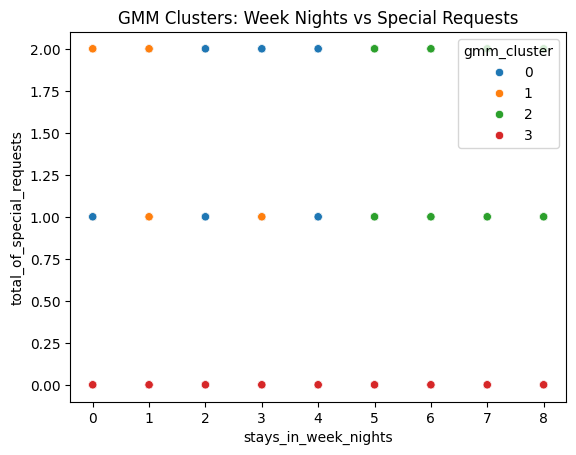

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests
gmm_cluster,,,,,
0,131.772912,0.859335,2.298582,110.423695,1.318985
1,20.799397,0.735586,1.899575,111.733777,1.281644
2,122.712577,2.095863,5.154511,113.029289,1.297392
3,77.663027,1.042082,2.630177,102.453567,0.000000


In [10]:
gmm = GaussianMixture(n_components=4, random_state=42)
cluster_data["gmm_cluster"] = gmm.fit_predict(X_scaled)

# Get probabilities for soft clustering
gmm_probabilities = gmm.predict_proba(X_scaled)

# Visualization 1
sns.scatterplot(data=cluster_data, x="lead_time", y="adr", hue="gmm_cluster", palette="tab10")
plt.title("GMM Clusters: Lead Time vs ADR")
plt.show()

# Visualization 2
sns.scatterplot(data=cluster_data, x="stays_in_week_nights", y="total_of_special_requests", hue="gmm_cluster", palette="tab10")
plt.title("GMM Clusters: Week Nights vs Special Requests")
plt.show()

gmm_summary = cluster_data.groupby("gmm_cluster")[features].mean()

display(gmm_summary)

### Reflection:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?

### ✍️ Your Response: 🔧
1. The GMM results has proabilities of multiple clusters instead of separate groups, so there is a bit more overlap between the segments compared to the KMeans.

2. GMM could help answer questions better about whose behavior overlaps multiple segments.


## 5. Evaluate Your Models

### Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

### Do the following:
- 5.1 Calculate the following **for each** of the models:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index

  **NOTE:** This step may take up to 5 minutes.  It is a lot of computation time.  Please be patient.  Or you can limit the scores to using a random sample of 10K rows.

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

In [12]:
# Use a random sample of 10,000 rows for silhouette score
np.random.seed(42)
sample_size = min(10000, len(X_scaled))
sample_idx = np.random.choice(len(X_scaled), size=sample_size, replace=False)

# KMeans metrics
kmeans_wcss = kmeans.inertia_

kmeans_silhouette = silhouette_score(X_scaled[sample_idx], cluster_data["kmeans_cluster"].values[sample_idx])

kmeans_db = davies_bouldin_score(X_scaled, cluster_data["kmeans_cluster"])

# Calculate GMM WCSS
gmm_labels = cluster_data["gmm_cluster"].values

gmm_wcss = 0

for cluster in np.unique(gmm_labels):
    points = X_scaled[gmm_labels == cluster]
    center = points.mean(axis=0)
    gmm_wcss += ((points - center) ** 2).sum()

gmm_silhouette = silhouette_score(X_scaled[sample_idx], gmm_labels[sample_idx])

gmm_db = davies_bouldin_score(X_scaled, gmm_labels)

results = pd.DataFrame({
    "Model": ["KMeans", "GMM"],
    "WCSS": [kmeans_wcss, gmm_wcss],
    "Silhouette Score": [kmeans_silhouette, gmm_silhouette],
    "Davies-Bouldin Index": [kmeans_db, gmm_db]})

display(results)

,Model,WCSS,Silhouette Score,Davies-Bouldin Index
0,KMeans,197389.691709,0.193767,1.627410
1,GMM,229004.512684,0.121608,1.893876


### Reflection:
5.2. Which model performed better on the metrics?

5.3. Would you recommend KMeans or GMM for a business analyst? Why?

### ✍️ Your Response: 🔧
5.2. KMeans performed better on the metrics.

5.3. For a business analyst, I recommend KMeans because it performed better on the metrics and it can be easier to explain to managers.


## 6. Business Interpretation

### Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

### Do the following:
- Display the characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Sort the clusters to make the differences more clear

In [14]:
cluster_characteristics = (cluster_data.groupby("kmeans_cluster")[features].mean().round(2))

# Sort by lead time to make differences clearer
cluster_characteristics = cluster_characteristics.sort_values(by="lead_time")

display(cluster_characteristics)

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests
kmeans_cluster,,,,,
1,38.69,0.76,1.92,100.81,0.00
3,40.60,0.75,1.98,111.84,1.33
2,115.77,2.12,5.08,106.42,0.62
0,187.68,0.87,2.48,110.11,0.62


### Reflection:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?

### ✍️ Your Response: 🔧
1. In terms of guest behavior, one of the segments represents early planners who book early, another represents short-term guests with very little special requests, another represents guests who stay longer, and the last segment represents guests who make many special requests who pay more.

2. The hotel can tailor to each group by sending earlier booking promotions to early planners, cheaper prices for shorter-team guests, extra packages for long-stay guests, and upgrade rooms or services for high-request guests.


## 7. Final Reflection

### Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### Reflection:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. The most challenging part about unsupervised learning was deciding how many cluster and interpreting what they actually mean. I had to interpret the clusters by evaluating them.

2. I would use clustering instead of supervised models when there is no target variable that we know of.

3. TO a non-technical manager, I would explain the value of clustering as a way of grouping customers who have similar behaviors.

4. This relates to my customized learning outcomes I created on canvas because it was to build and evaluate a model that forecasts revenue to guide budgeting or investment decisions. From the assignment, I was able to create segments that can identify different types of customers that generate revenue. By understanding this, I can make better budgeting and investment decisions.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [ ]:
!jupyter nbconvert --to html "assignment_09_clustering.ipynb"